In [4]:
import pandas as pd 
import matplotlib.pyplot as plt

In [5]:
dataset = pd.read_csv('creditcard.csv')

In [6]:
print("---Class distribution ---")
print(dataset['Class'].value_counts())


---Class distribution ---
Class
0    284315
1       492
Name: count, dtype: int64



 Percentage of fraudulent transactions is 0.1727%


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (1).

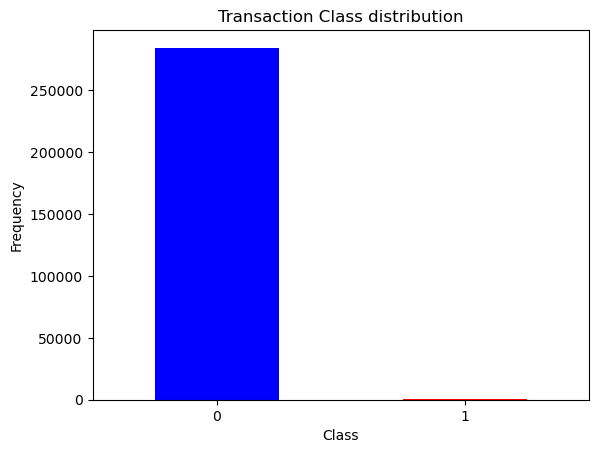

In [7]:
fraud_percentage = (dataset['Class'].value_counts()[1] / len(dataset)) * 100
print(f"\n Percentage of fraudulent transactions is {fraud_percentage:.4f}%")

dataset['Class'].value_counts().plot(kind = 'bar' , rot = 0 , color = ['blue' , 'red' ])
plt.title('Transaction Class distribution')
plt.ylabel('Frequency')
plt.xticks(range(2), ['legitimate (0) , fraud (1) '] )
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X  = dataset.drop('Class' , axis = 1 )
y = dataset['Class']

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.20 , random_state = 42 , stratify = y )

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print(f"Fraud cases in test set: {y_test.sum()}")

Training set size: 227845 rows
Testing set size: 56962 rows
Fraud cases in test set: 98


In [9]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10,random_state=42, n_jobs=10)


model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [10]:
from sklearn.metrics import classification_report , confusion_matrix

predictions = model.predict(X_test)

print("---Confusion matrix ---")
print(confusion_matrix(y_test,predictions))

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

---Confusion matrix ---
[[56846    18]
 [   17    81]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

neg_count = (y_train == 0).sum()
pos_count = (y_train == 0).sum()
base_weight = neg_count / pos_count

param_distributions = {
    'n_estimators' : [50,100,150],
    'max_depth' : [4,5,8],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'scale_pos_weight': [base_weight, base_weight * 0.5, base_weight * 1.5],
    'num_leaves': [15, 31, 63]
}

lgb_model = LGBMClassifier(n_jobs = 10 , random_state = 42 , verbose = -1)
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='f1',  # Optimize for F1-score because accuracy is useless for fraud
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1  # Keep this at 1 because LightGBM is already utilizing all 10 cores internally
)
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# 6. Extract the best model
best_model = random_search.best_estimator_
print("\nBest Hyperparameters Found:")
print(random_search.best_params_)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict using the optimized model
tuned_predictions = best_model.predict(X_test)

print("--- Optimized LightGBM Performance ---")
print(confusion_matrix(y_test, tuned_predictions))
print(classification_report(y_test, tuned_predictions))